# Pose Sequence Visualizer

This notebook provides comprehensive visualization tools for pose sequences captured by the MediaPipe handler.

## Features:
- Load and visualize pose sequences from pickle files
- Visualize individual pose landmarks
- Create 3D pose animations
- Analyze pose sequences over time
- Compare different workout types
- Export visualizations


In [17]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.animation as animation
import pickle
import os
import sys
from IPython.display import HTML
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Add the mediapipe_handler to the path
sys.path.append('src/mediapipe_handler')
from mediapipe_handler import MediaPipeHandler

# Set up plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Libraries imported successfully!")


Libraries imported successfully!


## 1. Data Loading Functions


In [18]:
def load_sequence_data(pickle_path='src/mediapipe_handler/sequences_labels_tuple.pkl'):
    """Load pose sequences and labels from pickle file"""
    try:
        with open(pickle_path, 'rb') as f:
            sequences, labels = pickle.load(f)
        print(f"Loaded {len(sequences)} sequences with labels")
        print(f"Sequence shape: {sequences[0].shape if len(sequences) > 0 else 'No sequences'}")
        print(f"Unique labels: {np.unique(labels)}")
        return sequences, labels
    except FileNotFoundError:
        print(f"Pickle file not found at {pickle_path}")
        return None, None
    except Exception as e:
        print(f"Error loading pickle file: {e}")
        return None, None

def load_csv_data(csv_path='data/datasets/train.csv'):
    """Load pose data from CSV file"""
    try:
        df = pd.read_csv(csv_path)
        print(f"Loaded CSV with {len(df)} rows")
        print(f"Columns: {list(df.columns)}")
        return df
    except FileNotFoundError:
        print(f"CSV file not found at {csv_path}")
        return None
    except Exception as e:
        print(f"Error loading CSV file: {e}")
        return None

# Load the data
sequences, labels = load_sequence_data()
csv_data = load_csv_data()


Loaded 4234 sequences with labels
Sequence shape: (90, 36)
Unique labels: ['barbell biceps curl' 'bench press' 'chest fly machine' 'deadlift'
 'decline bench press' 'hammer curl' 'hip thrust' 'incline bench press'
 'lat pulldown' 'lateral raise' 'leg extension' 'leg raises' 'plank'
 'pull Up' 'push-up' 'romanian deadlift' 'russian twist' 'shoulder press'
 'squat' 't bar row' 'tricep Pushdown' 'tricep dips']
Loaded CSV with 78579 rows
Columns: ['Unnamed: 0', 'image', 'label', 'muscle group', 'left_shoulder', 'right_shoulder', 'left_elbow', 'right_elbow', 'left_wrist', 'right_wrist', 'left_hip', 'right_hip', 'left_knee', 'right_knee', 'left_ankle', 'right_ankle']


## 2. Pose Landmark Visualization Functions


In [19]:
# Define pose landmark connections and names
POSE_CONNECTIONS = [
    # Arms
    (0, 2), (2, 4),  # Left arm: shoulder -> elbow -> wrist
    (1, 3), (3, 5),  # Right arm: shoulder -> elbow -> wrist
    # Torso
    (0, 1), (0, 6), (1, 7), (6, 7),  # Shoulders and hips
    # Legs
    (6, 8), (8, 10),   # Left leg: hip -> knee -> ankle
    (7, 9), (9, 11),   # Right leg: hip -> knee -> ankle
]

LANDMARK_NAMES = [
    'Left Shoulder', 'Right Shoulder', 'Left Elbow', 'Right Elbow',
    'Left Wrist', 'Right Wrist', 'Left Hip', 'Right Hip',
    'Left Knee', 'Right Knee', 'Left Ankle', 'Right Ankle'
]

def visualize_pose_3d(pose_coords, title="3D Pose Visualization", ax=None):
    """Visualize a single pose in 3D"""
    if ax is None:
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111, projection='3d')
    
    # Extract coordinates
    x, y, z = pose_coords[:, 0], pose_coords[:, 1], pose_coords[:, 2]
    
    # Plot landmarks - use keyword arguments to avoid conflicts
    ax.scatter(x, y, z, s=100, c='red', alpha=0.8)
    
    # Draw connections
    for connection in POSE_CONNECTIONS:
        start_idx, end_idx = connection
        if start_idx < len(pose_coords) and end_idx < len(pose_coords):
            ax.plot([x[start_idx], x[end_idx]], 
                   [y[start_idx], y[end_idx]], 
                   [z[start_idx], z[end_idx]], 'b-', linewidth=2)
    
    # Add labels
    for i, name in enumerate(LANDMARK_NAMES):
        if i < len(pose_coords):
            ax.text(x[i], y[i], z[i], f'  {name}', fontsize=8)
    
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title(title)
    
    return ax

def visualize_pose_2d(pose_coords, title="2D Pose Visualization", ax=None):
    """Visualize a single pose in 2D (X-Y projection)"""
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))
    
    # Extract coordinates (use X-Y projection)
    x, y = pose_coords[:, 0], pose_coords[:, 1]
    
    # Plot landmarks - use keyword arguments to avoid conflicts
    ax.scatter(x, y, s=100, c='red', alpha=0.8)
    
    # Draw connections
    for connection in POSE_CONNECTIONS:
        start_idx, end_idx = connection
        if start_idx < len(pose_coords) and end_idx < len(pose_coords):
            ax.plot([x[start_idx], x[end_idx]], 
                   [y[start_idx], y[end_idx]], 'b-', linewidth=2)
    
    # Add labels
    for i, name in enumerate(LANDMARK_NAMES):
        if i < len(pose_coords):
            ax.text(x[i], y[i], f'  {name}', fontsize=8)
    
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    
    return ax


## 3. Sequence Animation Functions


In [20]:
def create_pose_animation(sequence, title="Pose Sequence Animation", interval=100):
    """Create an animated visualization of a pose sequence"""
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    def animate(frame):
        ax.clear()
        pose = sequence[frame]
        
        # Reshape pose data (assuming it's flattened)
        if pose.ndim == 1:
            pose = pose.reshape(-1, 3)
        
        # Plot landmarks directly on the existing axis
        x, y, z = pose[:, 0], pose[:, 1], pose[:, 2]
        ax.scatter(x, y, z, s=100, c='red', alpha=0.8)
        
        # Draw connections
        for connection in POSE_CONNECTIONS:
            start_idx, end_idx = connection
            if start_idx < len(pose) and end_idx < len(pose):
                ax.plot([x[start_idx], x[end_idx]], 
                       [y[start_idx], y[end_idx]], 
                       [z[start_idx], z[end_idx]], 'b-', linewidth=2)
        
        # Add labels
        for i, name in enumerate(LANDMARK_NAMES):
            if i < len(pose):
                ax.text(x[i], y[i], z[i], f'  {name}', fontsize=8)
        
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_zlabel('Z')
        ax.set_title(f"{title} - Frame {frame}")
        
        # Set consistent axis limits
        ax.set_xlim([0, 1])
        ax.set_ylim([0, 1])
        ax.set_zlim([-1, 1])
    
    anim = animation.FuncAnimation(fig, animate, frames=len(sequence), 
                                 interval=interval, repeat=True)
    
    return anim

def create_trajectory_plot(sequence, landmark_idx=0, title="Landmark Trajectory"):
    """Plot the trajectory of a specific landmark over time"""
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Extract trajectory for the specified landmark
    trajectory = []
    for frame in sequence:
        if frame.ndim == 1:
            frame = frame.reshape(-1, 3)
        if landmark_idx < len(frame):
            trajectory.append(frame[landmark_idx])
    
    trajectory = np.array(trajectory)
    
    # Plot trajectory
    ax.plot(trajectory[:, 0], trajectory[:, 1], trajectory[:, 2], 
           'b-', linewidth=2, alpha=0.7)
    ax.scatter(trajectory[:, 0], trajectory[:, 1], trajectory[:, 2], 
              s=50, c=range(len(trajectory)), cmap='viridis')
    
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title(f"{title} - {LANDMARK_NAMES[landmark_idx]}")
    
    return fig


## 4. Data Analysis Functions


In [21]:
def analyze_sequence_statistics(sequences, labels):
    """Analyze basic statistics of pose sequences"""
    if sequences is None or len(sequences) == 0:
        print("No sequences available for analysis")
        return
    
    print("=== Sequence Statistics ===")
    print(f"Total sequences: {len(sequences)}")
    print(f"Sequence length: {sequences[0].shape[0] if len(sequences) > 0 else 'N/A'}")
    print(f"Pose dimensions: {sequences[0].shape[1] if len(sequences) > 0 else 'N/A'}")
    
    # Label distribution
    unique_labels, counts = np.unique(labels, return_counts=True)
    print("\nLabel distribution:")
    for label, count in zip(unique_labels, counts):
        print(f"  Label {label}: {count} sequences")
    
    # Sequence length distribution
    lengths = [len(seq) for seq in sequences]
    print(f"\nSequence length stats:")
    print(f"  Min: {min(lengths)}")
    print(f"  Max: {max(lengths)}")
    print(f"  Mean: {np.mean(lengths):.2f}")
    print(f"  Std: {np.std(lengths):.2f}")

def plot_label_distribution(labels):
    """Plot the distribution of labels"""
    if labels is None or len(labels) == 0:
        print("No labels available for plotting")
        return
    
    unique_labels, counts = np.unique(labels, return_counts=True)
    
    plt.figure(figsize=(12, 6))
    plt.bar(unique_labels, counts, alpha=0.7)
    plt.xlabel('Label')
    plt.ylabel('Count')
    plt.title('Distribution of Pose Sequence Labels')
    plt.grid(True, alpha=0.3)
    plt.show()

def plot_pose_variability(sequences, labels, max_sequences_per_label=10):
    """Plot pose variability across different labels"""
    if sequences is None or len(sequences) == 0:
        print("No sequences available for analysis")
        return
    
    unique_labels = np.unique(labels)
    n_labels = len(unique_labels)
    
    fig, axes = plt.subplots(2, (n_labels + 1) // 2, figsize=(15, 10))
    axes = axes.flatten() if n_labels > 1 else [axes]
    
    for i, label in enumerate(unique_labels):
        if i >= len(axes):
            break
            
        # Get sequences for this label
        label_sequences = [seq for seq, lab in zip(sequences, labels) if lab == label]
        
        # Sample a few sequences for visualization
        sample_sequences = label_sequences[:max_sequences_per_label]
        
        ax = axes[i]
        
        # Plot first frame of each sequence
        for j, seq in enumerate(sample_sequences):
            if seq.ndim == 1:
                pose = seq.reshape(-1, 3)
            else:
                pose = seq[0].reshape(-1, 3)
            
            x, y = pose[:, 0], pose[:, 1]
            ax.scatter(x, y, s=30, alpha=0.6)
        
        ax.set_title(f'Label {label} - Pose Variability')
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.grid(True, alpha=0.3)
    
    # Hide unused subplots
    for i in range(len(unique_labels), len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    plt.show()


## 5. Interactive Visualization Functions


In [22]:
def visualize_sequence_comparison(sequences, labels, label1, label2, max_sequences=5):
    """Compare pose sequences between two labels"""
    if sequences is None or len(sequences) == 0:
        print("No sequences available for comparison")
        return
    
    # Get sequences for each label
    seq1 = [seq for seq, lab in zip(sequences, labels) if lab == label1][:max_sequences]
    seq2 = [seq for seq, lab in zip(sequences, labels) if lab == label2][:max_sequences]
    
    fig, axes = plt.subplots(2, max_sequences, figsize=(15, 8))
    
    for i in range(max_sequences):
        # Plot label1 sequences
        if i < len(seq1):
            pose = seq1[i][0].reshape(-1, 3) if seq1[i].ndim > 1 else seq1[i].reshape(-1, 3)
            visualize_pose_2d(pose, f"Label {label1} - Seq {i+1}", axes[0, i])
        
        # Plot label2 sequences
        if i < len(seq2):
            pose = seq2[i][0].reshape(-1, 3) if seq2[i].ndim > 1 else seq2[i].reshape(-1, 3)
            visualize_pose_2d(pose, f"Label {label2} - Seq {i+1}", axes[1, i])
    
    plt.tight_layout()
    plt.show()

def create_pose_heatmap(sequences, labels, landmark_idx=0):
    """Create a heatmap showing pose landmark positions across sequences"""
    if sequences is None or len(sequences) == 0:
        print("No sequences available for heatmap")
        return
    
    # Extract landmark positions
    positions = []
    sequence_labels = []
    
    for seq, label in zip(sequences, labels):
        for frame in seq:
            if frame.ndim == 1:
                frame = frame.reshape(-1, 3)
            if landmark_idx < len(frame):
                positions.append(frame[landmark_idx])
                sequence_labels.append(label)
    
    positions = np.array(positions)
    
    # Create 2D histogram
    plt.figure(figsize=(10, 8))
    plt.hist2d(positions[:, 0], positions[:, 1], bins=50, cmap='Blues')
    plt.colorbar(label='Count')
    plt.xlabel('X Position')
    plt.ylabel('Y Position')
    plt.title(f'Position Heatmap - {LANDMARK_NAMES[landmark_idx]}')
    plt.show()


## 6. Main Visualization Examples


=== Sequence Statistics ===
Total sequences: 4234
Sequence length: 90
Pose dimensions: 36

Label distribution:
  Label barbell biceps curl: 140 sequences
  Label bench press: 76 sequences
  Label chest fly machine: 176 sequences
  Label deadlift: 169 sequences
  Label decline bench press: 29 sequences
  Label hammer curl: 103 sequences
  Label hip thrust: 187 sequences
  Label incline bench press: 209 sequences
  Label lat pulldown: 132 sequences
  Label lateral raise: 202 sequences
  Label leg extension: 115 sequences
  Label leg raises: 120 sequences
  Label plank: 551 sequences
  Label pull Up: 294 sequences
  Label push-up: 342 sequences
  Label romanian deadlift: 246 sequences
  Label russian twist: 213 sequences
  Label shoulder press: 146 sequences
  Label squat: 200 sequences
  Label t bar row: 196 sequences
  Label tricep Pushdown: 128 sequences
  Label tricep dips: 260 sequences

Sequence length stats:
  Min: 90
  Max: 90
  Mean: 90.00
  Std: 0.00


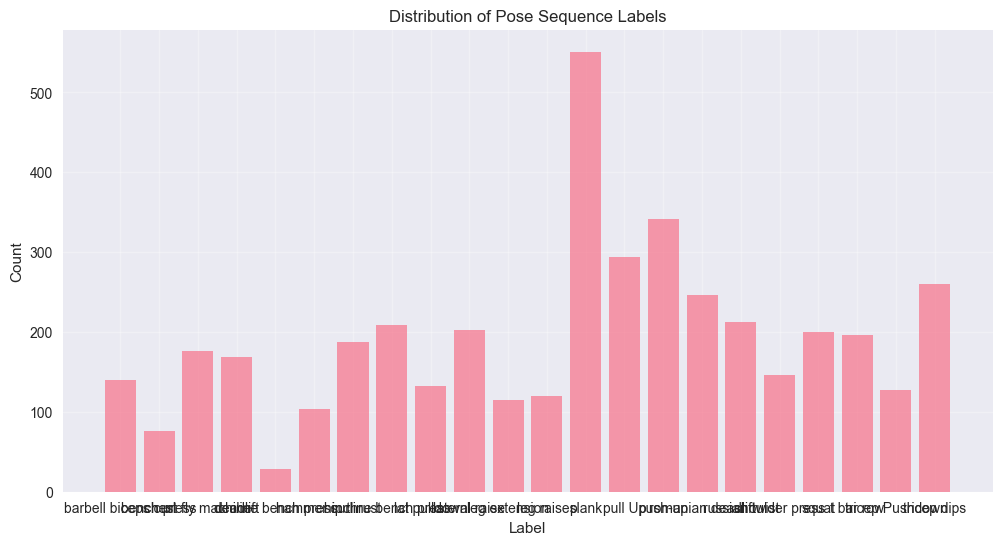

In [23]:
# Analyze the loaded data
if sequences is not None and labels is not None:
    analyze_sequence_statistics(sequences, labels)
    plot_label_distribution(labels)
else:
    print("No sequence data available. Please check the pickle file path.")



=== Visualizing Individual Poses from CSV ===


TypeError: Axes.scatter() got multiple values for argument 's'

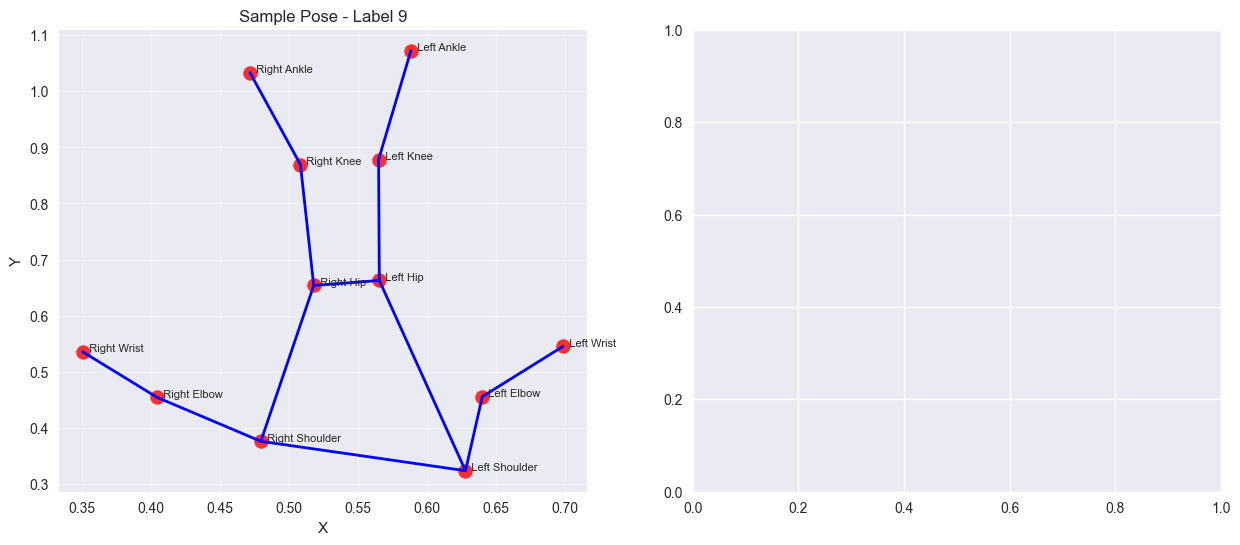

In [24]:
# Visualize individual poses if CSV data is available
if csv_data is not None:
    print("\n=== Visualizing Individual Poses from CSV ===")
    
    # Convert string representations to numpy arrays
    def parse_coords(coord_str):
        try:
            # Remove brackets and split by spaces
            coords = coord_str.strip('[]').split()
            return np.array([float(x) for x in coords])
        except:
            return np.array([])
    
    # Parse coordinates for a sample row
    sample_row = csv_data.iloc[0]
    pose_coords = []
    
    landmark_columns = ['left_shoulder', 'right_shoulder', 'left_elbow', 'right_elbow',
                      'left_wrist', 'right_wrist', 'left_hip', 'right_hip',
                      'left_knee', 'right_knee', 'left_ankle', 'right_ankle']
    
    for col in landmark_columns:
        coords = parse_coords(sample_row[col])
        if len(coords) == 3:
            pose_coords.append(coords)
    
    if len(pose_coords) == 12:
        pose_coords = np.array(pose_coords)
        
        # Visualize the pose
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
        
        visualize_pose_2d(pose_coords, f"Sample Pose - Label {sample_row['label']}", ax1)
        visualize_pose_3d(pose_coords, f"Sample Pose 3D - Label {sample_row['label']}", ax2)
        
        plt.tight_layout()
        plt.show()
    else:
        print("Could not parse pose coordinates properly")
else:
    print("No CSV data available. Please check the CSV file path.")



=== Pose Variability Analysis ===


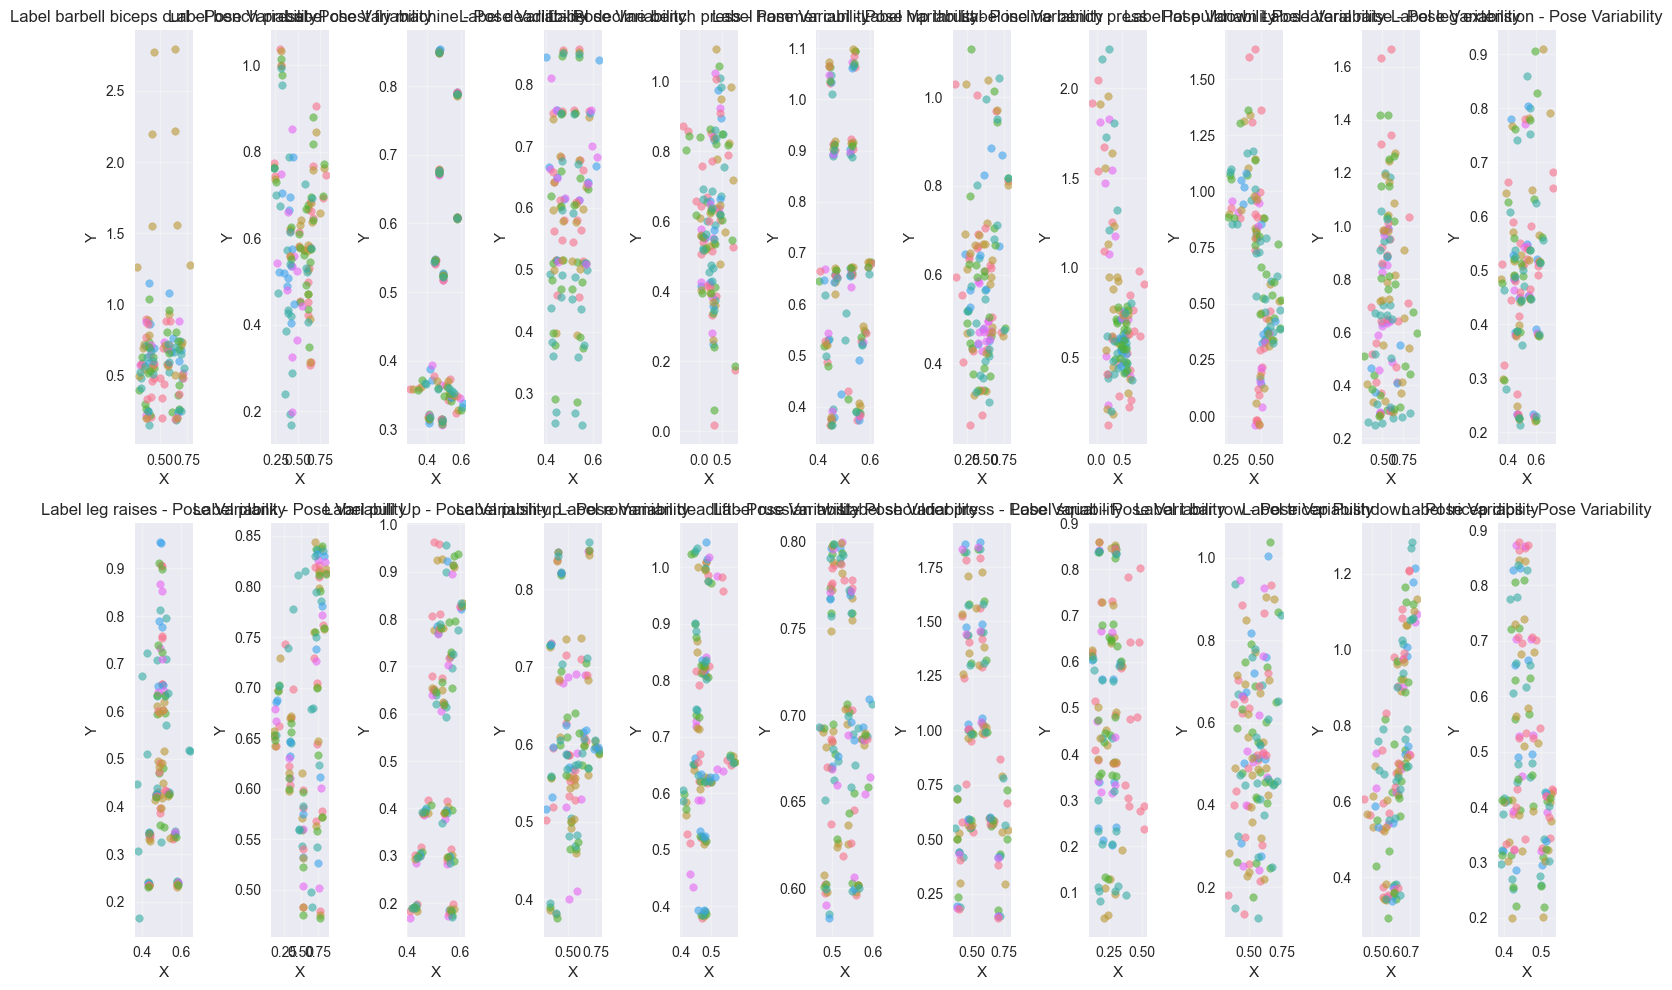

In [25]:
# Create pose variability plot if sequences are available
if sequences is not None and labels is not None:
    print("\n=== Pose Variability Analysis ===")
    plot_pose_variability(sequences, labels)
else:
    print("No sequence data available for variability analysis.")


In [26]:
# Create interactive slideshow for pose sequences
if sequences is not None and len(sequences) > 0:
    print("\n=== Creating Interactive Pose Sequence Slideshow ===")
    
    from ipywidgets import interact, IntSlider, Dropdown
    import ipywidgets as widgets
    
    def create_pose_slideshow():
        """Create an interactive slideshow for pose sequences"""
        
        # Get available sequences
        sequence_options = [(f"Sequence {i} (Label: {labels[i]})", i) for i in range(len(sequences))]
        
        def display_frame(sequence_idx, frame_idx):
            """Display a specific frame from a sequence"""
            if sequence_idx >= len(sequences):
                return
            
            sequence = sequences[sequence_idx]
            if frame_idx >= len(sequence):
                frame_idx = len(sequence) - 1
            
            pose = sequence[frame_idx]
            
            # Reshape pose data if needed
            if pose.ndim == 1:
                pose = pose.reshape(-1, 3)
            
            # Create the plot
            fig = plt.figure(figsize=(12, 8))
            ax = fig.add_subplot(111, projection='3d')
            
            # Plot landmarks
            x, y, z = pose[:, 0], pose[:, 1], pose[:, 2]
            ax.scatter(x, y, z, s=100, c='red', alpha=0.8)
            
            # Draw connections
            for connection in POSE_CONNECTIONS:
                start_idx, end_idx = connection
                if start_idx < len(pose) and end_idx < len(pose):
                    ax.plot([x[start_idx], x[end_idx]], 
                           [y[start_idx], y[end_idx]], 
                           [z[start_idx], z[end_idx]], 'b-', linewidth=2)
            
            # Add labels
            for i, name in enumerate(LANDMARK_NAMES):
                if i < len(pose):
                    ax.text(x[i], y[i], z[i], f'  {name}', fontsize=8)
            
            ax.set_xlabel('X')
            ax.set_ylabel('Y')
            ax.set_zlabel('Z')
            ax.set_title(f"Sequence {sequence_idx} - Frame {frame_idx}/{len(sequence)-1} (Label: {labels[sequence_idx]})")
            ax.set_xlim([0, 1])
            ax.set_ylim([0, 1])
            ax.set_zlim([-1, 1])
            
            plt.tight_layout()
            plt.show()
        
        # Create interactive widgets
        sequence_dropdown = Dropdown(
            options=sequence_options,
            value=0,
            description='Sequence:',
            style={'description_width': 'initial'}
        )
        
        frame_slider = IntSlider(
            value=0,
            min=0,
            max=len(sequences[0])-1 if len(sequences) > 0 else 0,
            step=1,
            description='Frame:',
            style={'description_width': 'initial'},
            layout=widgets.Layout(width='500px')
        )
        
        def update_frame_slider(change):
            """Update frame slider when sequence changes"""
            sequence_idx = change['new']
            if sequence_idx < len(sequences):
                frame_slider.max = len(sequences[sequence_idx]) - 1
                frame_slider.value = 0
        
        sequence_dropdown.observe(update_frame_slider, names='value')
        
        # Create the interactive interface
        interact(display_frame, 
                sequence_idx=sequence_dropdown, 
                frame_idx=frame_slider)
    
    # Create the slideshow
    create_pose_slideshow()
    
else:
    print("No sequence data available for slideshow.")



=== Creating Interactive Pose Sequence Slideshow ===


interactive(children=(Dropdown(description='Sequence:', options=(('Sequence 0 (Label: deadlift)', 0), ('Sequen…


=== Simple Frame Navigation ===
Use the function below to navigate through frames manually:


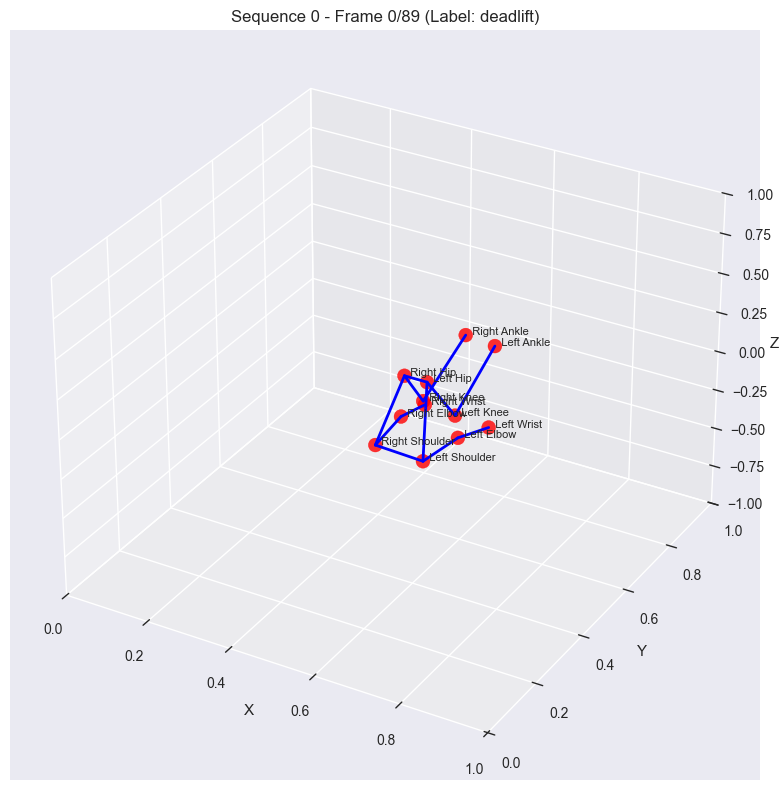

Displayed: Sequence 0, Frame 0
Available sequences: 0 to 4233
Available frames for this sequence: 0 to 89

To navigate:
- show_frame(0, 5)  # Show frame 5 of sequence 0
- show_frame(1, 10) # Show frame 10 of sequence 1
- etc.


In [27]:
# Alternative: Simple frame navigation without widgets
if sequences is not None and len(sequences) > 0:
    print("\n=== Simple Frame Navigation ===")
    print("Use the function below to navigate through frames manually:")
    
    def show_frame(sequence_idx=0, frame_idx=0):
        """Display a specific frame from a sequence"""
        if sequence_idx >= len(sequences):
            print(f"Sequence {sequence_idx} not available. Max sequence index: {len(sequences)-1}")
            return
        
        sequence = sequences[sequence_idx]
        if frame_idx >= len(sequence):
            print(f"Frame {frame_idx} not available for sequence {sequence_idx}. Max frame index: {len(sequence)-1}")
            return
        
        pose = sequence[frame_idx]
        
        # Reshape pose data if needed
        if pose.ndim == 1:
            pose = pose.reshape(-1, 3)
        
        # Create the plot
        fig = plt.figure(figsize=(12, 8))
        ax = fig.add_subplot(111, projection='3d')
        
        # Plot landmarks
        x, y, z = pose[:, 0], pose[:, 1], pose[:, 2]
        ax.scatter(x, y, z, s=100, c='red', alpha=0.8)
        
        # Draw connections
        for connection in POSE_CONNECTIONS:
            start_idx, end_idx = connection
            if start_idx < len(pose) and end_idx < len(pose):
                ax.plot([x[start_idx], x[end_idx]], 
                       [y[start_idx], y[end_idx]], 
                       [z[start_idx], z[end_idx]], 'b-', linewidth=2)
        
        # Add labels
        for i, name in enumerate(LANDMARK_NAMES):
            if i < len(pose):
                ax.text(x[i], y[i], z[i], f'  {name}', fontsize=8)
        
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_zlabel('Z')
        ax.set_title(f"Sequence {sequence_idx} - Frame {frame_idx}/{len(sequence)-1} (Label: {labels[sequence_idx]})")
        ax.set_xlim([0, 1])
        ax.set_ylim([0, 1])
        ax.set_zlim([-1, 1])
        
        plt.tight_layout()
        plt.show()
        
        print(f"Displayed: Sequence {sequence_idx}, Frame {frame_idx}")
        print(f"Available sequences: 0 to {len(sequences)-1}")
        print(f"Available frames for this sequence: 0 to {len(sequence)-1}")
    
    # Show first frame as example
    show_frame(0, 0)
    
    print("\nTo navigate:")
    print("- show_frame(0, 5)  # Show frame 5 of sequence 0")
    print("- show_frame(1, 10) # Show frame 10 of sequence 1")
    print("- etc.")
    
else:
    print("No sequence data available for frame navigation.")



=== Creating Trajectory Plot ===


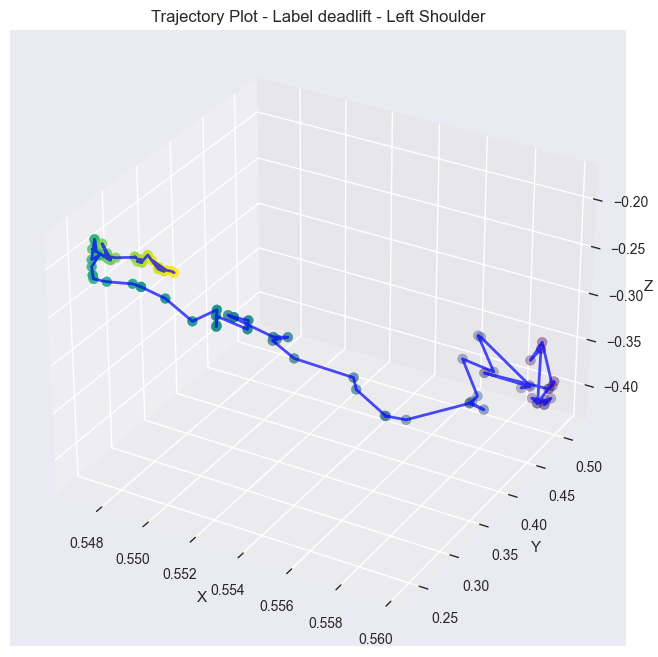

In [28]:
# Create trajectory plot if sequences are available
if sequences is not None and len(sequences) > 0:
    print("\n=== Creating Trajectory Plot ===")
    
    # Select a sequence and landmark
    selected_sequence = sequences[0]
    landmark_idx = 0  # Left shoulder
    
    # Create trajectory plot
    fig = create_trajectory_plot(selected_sequence, landmark_idx, 
                               f"Trajectory Plot - Label {labels[0]}")
    plt.show()
else:
    print("No sequence data available for trajectory analysis.")



=== Sequence Comparison ===


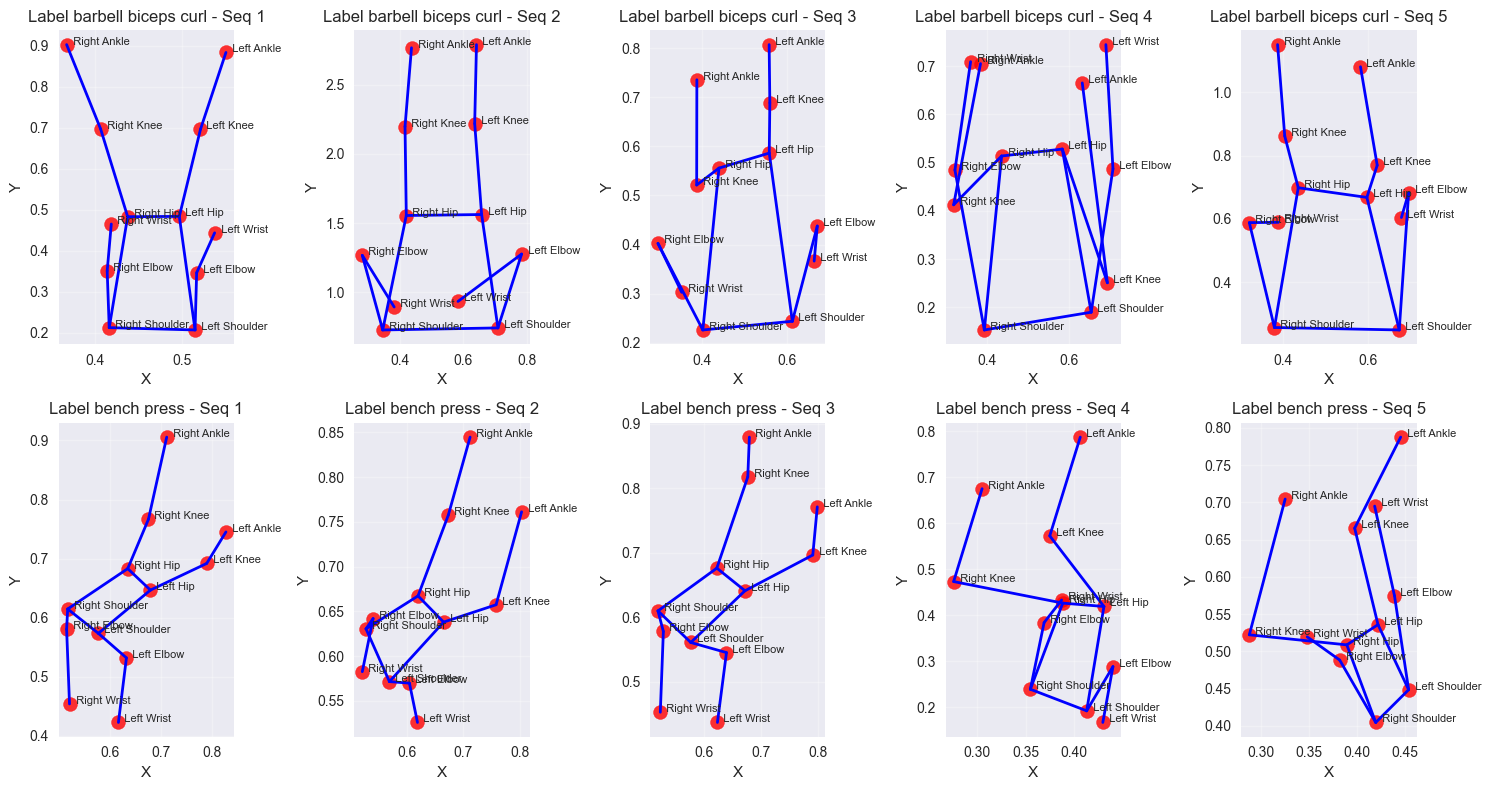

In [29]:
# Compare sequences between different labels
if sequences is not None and labels is not None:
    print("\n=== Sequence Comparison ===")
    
    unique_labels = np.unique(labels)
    if len(unique_labels) >= 2:
        visualize_sequence_comparison(sequences, labels, unique_labels[0], unique_labels[1])
    else:
        print("Need at least 2 different labels for comparison.")
else:
    print("No sequence data available for comparison.")



=== Creating Pose Heatmap ===


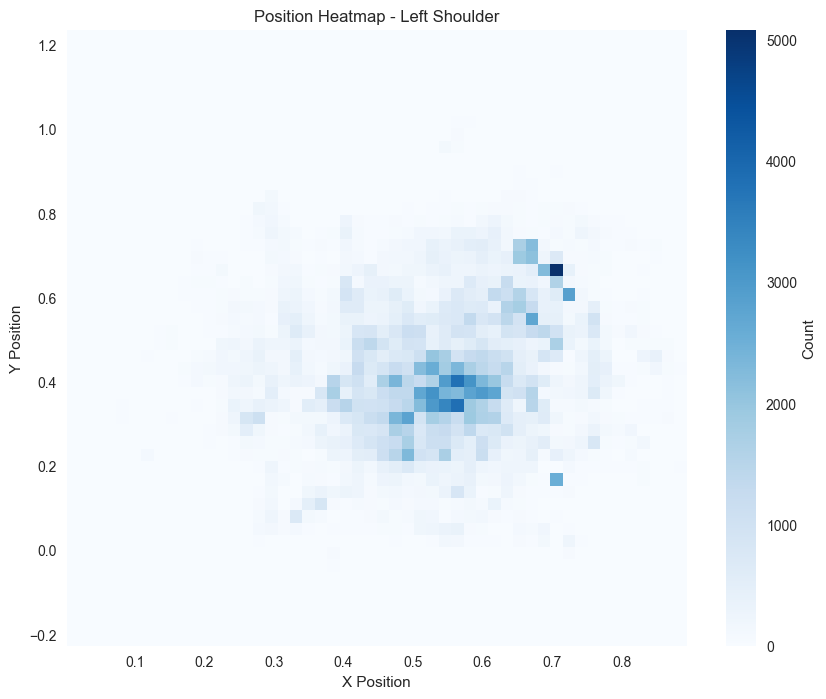

In [30]:
# Create pose heatmap if sequences are available
if sequences is not None and len(sequences) > 0:
    print("\n=== Creating Pose Heatmap ===")
    
    # Create heatmap for left shoulder (landmark 0)
    create_pose_heatmap(sequences, labels, landmark_idx=0)
else:
    print("No sequence data available for heatmap.")


## 7. Export Functions


In [31]:
def export_visualization_data(sequences, labels, output_dir='visualization_output'):
    """Export visualization data and plots"""
    import os
    
    # Create output directory
    os.makedirs(output_dir, exist_ok=True)
    
    if sequences is not None and labels is not None:
        # Export sequence statistics
        stats = {
            'total_sequences': len(sequences),
            'sequence_length': sequences[0].shape[0] if len(sequences) > 0 else 0,
            'pose_dimensions': sequences[0].shape[1] if len(sequences) > 0 else 0,
            'unique_labels': np.unique(labels).tolist(),
            'label_counts': {str(label): int(count) for label, count in zip(*np.unique(labels, return_counts=True))}
        }
        
        import json
        with open(f'{output_dir}/sequence_statistics.json', 'w') as f:
            json.dump(stats, f, indent=2)
        
        print(f"Exported statistics to {output_dir}/sequence_statistics.json")
    
    print(f"Visualization data exported to {output_dir}/")

# Export the data
export_visualization_data(sequences, labels)


Exported statistics to visualization_output/sequence_statistics.json
Visualization data exported to visualization_output/


## 8. Interactive Controls

Use the functions below to create custom visualizations:


Available labels: ['barbell biceps curl' 'bench press' 'chest fly machine' 'deadlift'
 'decline bench press' 'hammer curl' 'hip thrust' 'incline bench press'
 'lat pulldown' 'lateral raise' 'leg extension' 'leg raises' 'plank'
 'pull Up' 'push-up' 'romanian deadlift' 'russian twist' 'shoulder press'
 'squat' 't bar row' 'tricep Pushdown' 'tricep dips']
Total sequences: 4234


/var/folders/_t/g4q2zghj56dcd8_5f4ky178m0000gn/T/ipykernel_18410/1715731956.py:40: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


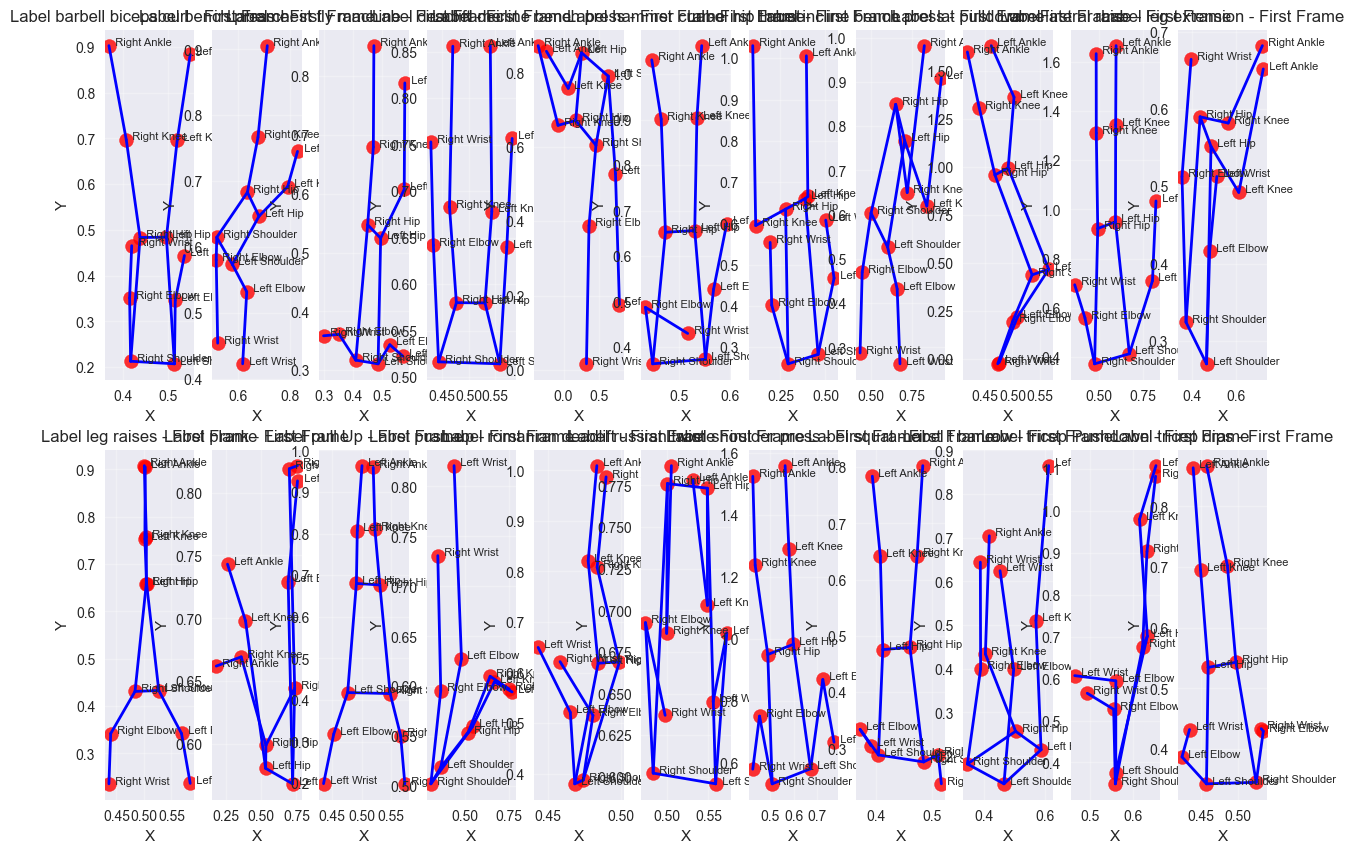

In [32]:
# Interactive visualization controls
def interactive_pose_visualizer():
    """Interactive function to visualize specific poses and sequences"""
    
    if sequences is None or len(sequences) == 0:
        print("No sequences available for interactive visualization")
        return
    
    print("Available labels:", np.unique(labels))
    print("Total sequences:", len(sequences))
    
    # Example: Visualize first sequence of each label
    unique_labels = np.unique(labels)
    
    fig, axes = plt.subplots(2, (len(unique_labels) + 1) // 2, figsize=(15, 10))
    axes = axes.flatten() if len(unique_labels) > 1 else [axes]
    
    for i, label in enumerate(unique_labels):
        if i >= len(axes):
            break
            
        # Find first sequence with this label
        label_indices = [j for j, lab in enumerate(labels) if lab == label]
        if label_indices:
            seq_idx = label_indices[0]
            sequence = sequences[seq_idx]
            
            # Visualize first frame
            if sequence.ndim == 1:
                pose = sequence.reshape(-1, 3)
            else:
                pose = sequence[0].reshape(-1, 3)
            
            visualize_pose_2d(pose, f"Label {label} - First Frame", axes[i])
    
    # Hide unused subplots
    for i in range(len(unique_labels), len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    plt.show()

# Run interactive visualizer
interactive_pose_visualizer()


## Summary

This notebook provides comprehensive visualization tools for pose sequences captured by the MediaPipe handler. The visualizations include:

1. **Individual Pose Visualization**: 2D and 3D pose landmark visualization
2. **Sequence Animation**: Animated sequences showing pose changes over time
3. **Trajectory Analysis**: Tracking specific landmark movements
4. **Statistical Analysis**: Distribution and variability analysis
5. **Comparative Visualization**: Comparing poses across different labels
6. **Heatmap Visualization**: Position density analysis

The notebook is designed to work with both sequence data (from pickle files) and individual pose data (from CSV files) captured by the MediaPipe handler.
